# New Section

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('Battery_dataset.csv')

# Features: charging (I, V, T), discharging (I, V, T), and Body Temp
features = ['chI', 'chV', 'chT', 'disI', 'disV', 'disT', 'BCt']
target = 'SOH'

# 1. Normalize the data (essential for Deep Learning)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

# 2. Windowing (Spatiotemporal extraction)
def create_cycle_windows(data, labels, window_size=10):
    X_list, y_list = [], []
    for i in range(len(data) - window_size):
        # Taking 'window_size' cycles as the spatial-temporal input
        X_list.append(data[i : i + window_size])
        y_list.append(labels[i + window_size])
    return np.array(X_list), np.array(y_list)

# Using a window of 10 cycles to predict the next SOH
WINDOW_SIZE = 10
X_3D, y_final = create_cycle_windows(X_scaled, y_scaled, window_size=WINDOW_SIZE)

# 3. Split data
X_train, X_val, y_train, y_val = train_test_split(X_3D, y_final, test_size=0.15, random_state=42)

print(f"Data ready. Input shape: {X_train.shape}") # (Samples, 10, 7)

Data ready. Input shape: (569, 10, 7)


In [2]:
import random
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

# 1. EXPANDED HYPERPARAMETER RANGES
PARAM_BOUNDS = {
    'cnn_filters': [32, 64, 128, 256],
    'kernel_size': [2, 3, 5],
    'lstm_units': [32, 64, 128, 256],
    'dense_units': [16, 32, 64, 128],
    'dropout_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'learning_rate': [0.01, 0.005, 0.001, 0.0005, 0.0001]
}

POP_SIZE = 12 # Slightly increased for diversity
GENERATIONS = 20

def create_individual():
    return {
        'cnn_filters': random.choice(PARAM_BOUNDS['cnn_filters']),
        'kernel_size': random.choice(PARAM_BOUNDS['kernel_size']),
        'lstm_units': random.choice(PARAM_BOUNDS['lstm_units']),
        'dense_units': random.choice(PARAM_BOUNDS['dense_units']),
        'dropout_rate': random.choice(PARAM_BOUNDS['dropout_rate']),
        'learning_rate': random.choice(PARAM_BOUNDS['learning_rate'])
    }

# 2. UPDATED SPATIOTEMPORAL MODEL (CNN + LSTM)
def build_and_train_model(config, X_train, y_train, X_val, y_val, input_shape):
    model = Sequential([
        # Spatial Layer: Conv1D captures correlations between chV, chI, BCt, etc.
        Conv1D(filters=config['cnn_filters'],
               kernel_size=config['kernel_size'],
               activation='relu',
               padding='same',
               input_shape=input_shape),
        MaxPooling1D(pool_size=2),

        # Temporal Layer: LSTM captures cycle-to-cycle degradation
        LSTM(config['lstm_units'], return_sequences=False),
        Dropout(config['dropout_rate']),

        Dense(config['dense_units'], activation='relu'),
        Dense(1) # Output SOH
    ])

    optimizer = Adam(learning_rate=config['learning_rate'])
    model.compile(optimizer=optimizer, loss='mse')

    # Training for 10 epochs during GA to balance speed and accuracy
    model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_val, y_val), verbose=0)

    y_pred = model.predict(X_val, verbose=0)
    return mean_squared_error(y_val, y_pred)

def fitness_function(individual, X_train, y_train, X_val, y_val):
    input_shape = (X_train.shape[1], X_train.shape[2])
    mse = build_and_train_model(individual, X_train, y_train, X_val, y_val, input_shape)
    return 1 / (mse + 1e-6)

# 3. ENHANCED GA OPERATORS
def select_parents(population, fitness_scores):
    # Tournament Selection (More robust than simple best-two)
    idx1, idx2 = random.sample(range(len(population)), 2)
    p1 = population[idx1] if fitness_scores[idx1] > fitness_scores[idx2] else population[idx2]

    idx3, idx4 = random.sample(range(len(population)), 2)
    p2 = population[idx3] if fitness_scores[idx3] > fitness_scores[idx4] else population[idx4]
    return p1, p2

def mutate(individual, mutation_rate=0.15):
    for key in individual:
        if random.random() < mutation_rate:
            individual[key] = random.choice(PARAM_BOUNDS[key])
    return individual

def evolve_population(population, fitness_scores, elite_count=2):
    new_population = []
    # Elitism: Directly pass the top 2 individuals to the next generation
    elite_indices = np.argsort(fitness_scores)[::-1][:elite_count]
    for i in elite_indices:
        new_population.append(population[i].copy())

    while len(new_population) < len(population):
        parent1, parent2 = select_parents(population, fitness_scores)
        child = {key: random.choice([parent1[key], parent2[key]]) for key in parent1}
        child = mutate(child)
        new_population.append(child)
    return new_population

# --- MAIN EXECUTION LOOP ---
population = [create_individual() for _ in range(POP_SIZE)]
best_fitness = -1
best_config = None

for gen in range(GENERATIONS):
    fitness_scores = [fitness_function(ind, X_train, y_train, X_val, y_val) for ind in population]

    current_best_idx = np.argmax(fitness_scores)
    if fitness_scores[current_best_idx] > best_fitness:
        best_fitness = fitness_scores[current_best_idx]
        best_config = population[current_best_idx].copy()

    print(f"Gen {gen+1}: Best Fitness = {best_fitness:.4f} | MSE = {1/best_fitness:.6f}")
    population = evolve_population(population, fitness_scores)

print("\nOptimization Finished!")
print("-" * 30)
print(f"Optimal Hyperparameters: {best_config}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

Gen 1: Best Fitness = 111.1683 | MSE = 0.008995


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

Gen 2: Best Fitness = 111.1683 | MSE = 0.008995


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

...

Gen 18: Best Fitness = 130.6440 | MSE = 0.007654


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

Gen 19: Best Fitness = 130.6440 | MSE = 0.007654


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

Gen 20: Best Fitness = 130.6440 | MSE = 0.007654

Optimization Finished!
------------------------------
Optimal Hyperparameters: {'cnn_filters': 256, 'kernel_size': 2, 'lstm_units': 256, 'dense_units': 16, 'dropout_rate': 0.3, 'learning_rate': 0.005}


In [3]:
import matplotlib.pyplot as plt

def build_spatiotemporal_model(lstm_units, dense_units, dropout_rate, learning_rate, input_shape):
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(lstm_units, return_sequences=False),
        Dropout(dropout_rate),
        Dense(dense_units, activation='relu'),
        Dense(1) # Output layer for SOH prediction
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# 1. Build the final model using EGA's best parameters
final_model = build_spatiotemporal_model(
    lstm_units=best_config['lstm_units'],
    dense_units=best_config['dense_units'],
    dropout_rate=best_config['dropout_rate'],
    learning_rate=best_config['learning_rate'],
    input_shape=(WINDOW_SIZE, len(features))
)

# 2. Final Training (increase epochs for full convergence)
history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

# 3. Predict SOH
y_pred_scaled = final_model.predict(X_val)

# 4. Inverse Transform to get actual SOH percentages back
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_val)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - loss: 0.1310 - val_loss: 0.0215
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0157 - val_loss: 0.0152
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0116 - val_loss: 0.0249
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0146 - val_loss: 0.0172
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0092 - val_loss: 0.0170
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0069 - val_loss: 0.0164
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0063 - val_loss: 0.0150
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0052 - val_loss: 0.0162
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0059 - val_loss: 0.0148
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0074 - val_loss: 0.0128
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0050 - val_loss: 0.0118
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0

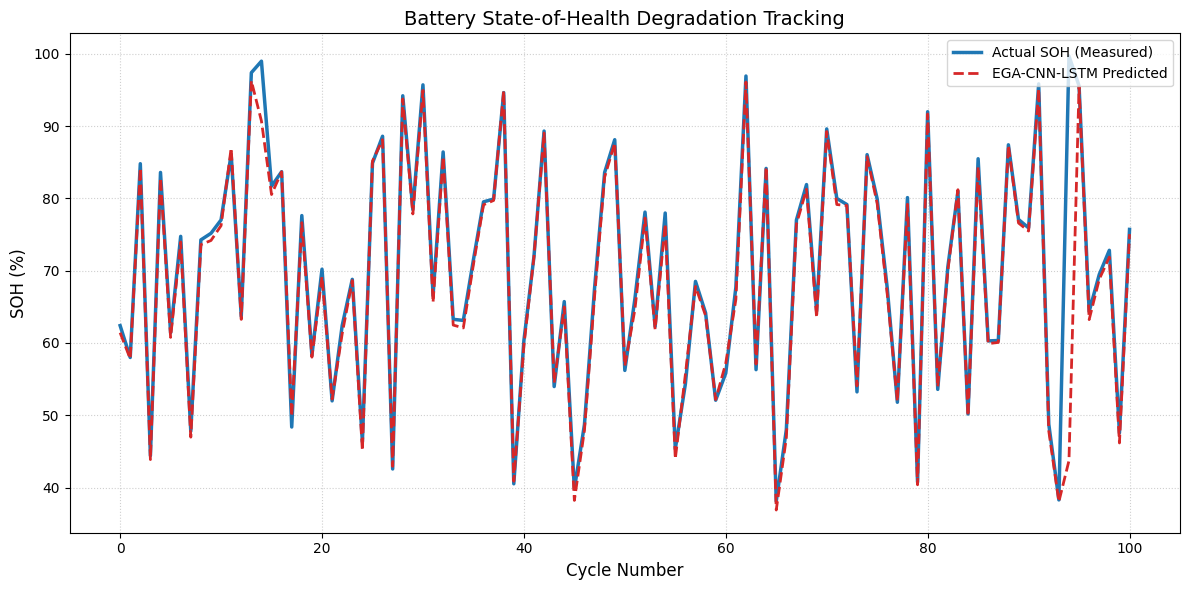

In [9]:
def plot_soh_tracking(y_actual, y_pred):
    plt.figure(figsize=(12, 6))
    plt.plot(y_actual, label='Actual SOH (Measured)', color='#1f77b4', linewidth=2.5)
    plt.plot(y_pred, label='EGA-CNN-LSTM Predicted', color='#d62728', linestyle='--', linewidth=2)
    plt.title('Battery State-of-Health Degradation Tracking', fontsize=14)
    plt.xlabel('Cycle Number', fontsize=12)
    plt.ylabel('SOH (%)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_soh_tracking(y_actual, y_pred)

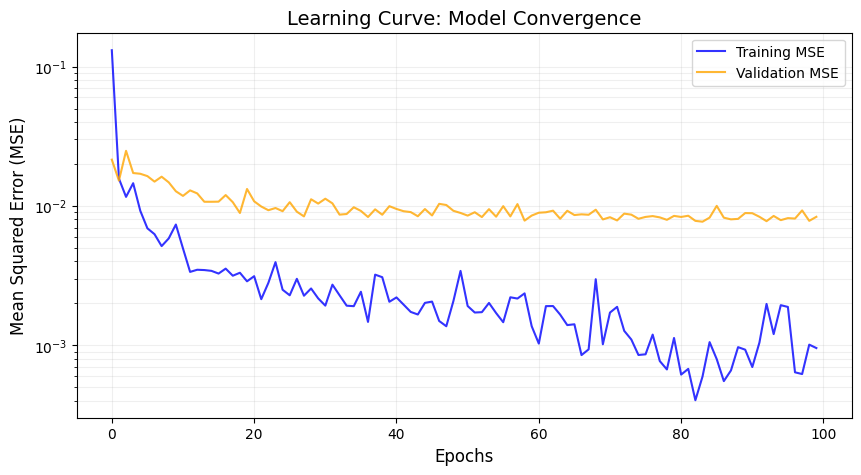

In [10]:
def plot_convergence(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training MSE', color='blue', alpha=0.8)
    plt.plot(history.history['val_loss'], label='Validation MSE', color='orange', alpha=0.8)
    plt.title('Learning Curve: Model Convergence', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.yscale('log') # Log scale helps visualize fine-tuning in later epochs
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_convergence(history)

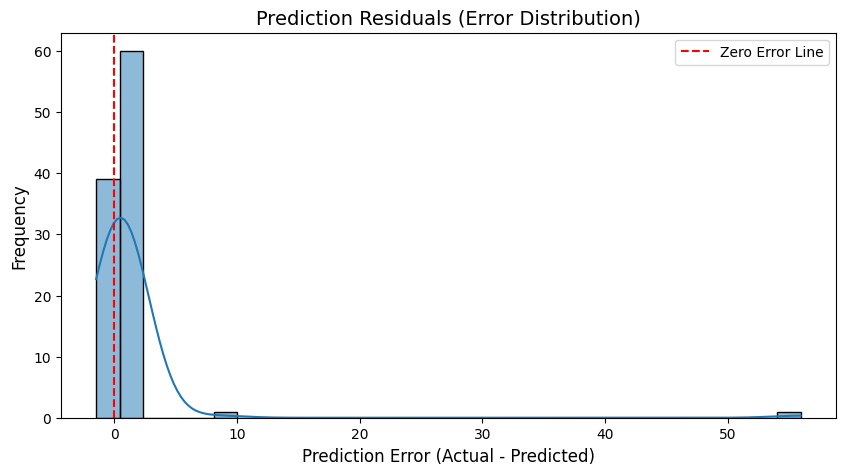

In [11]:
def plot_error_distribution(y_actual, y_pred):
    plt.figure(figsize=(10, 5))
    residuals = y_actual - y_pred
    sns.histplot(residuals, bins=30, kde=True, color='purple', edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', label='Zero Error Line')
    plt.title('Prediction Residuals (Error Distribution)', fontsize=14)
    plt.xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.show()

import seaborn as sns # For KDE curve
plot_error_distribution(y_actual, y_pred)

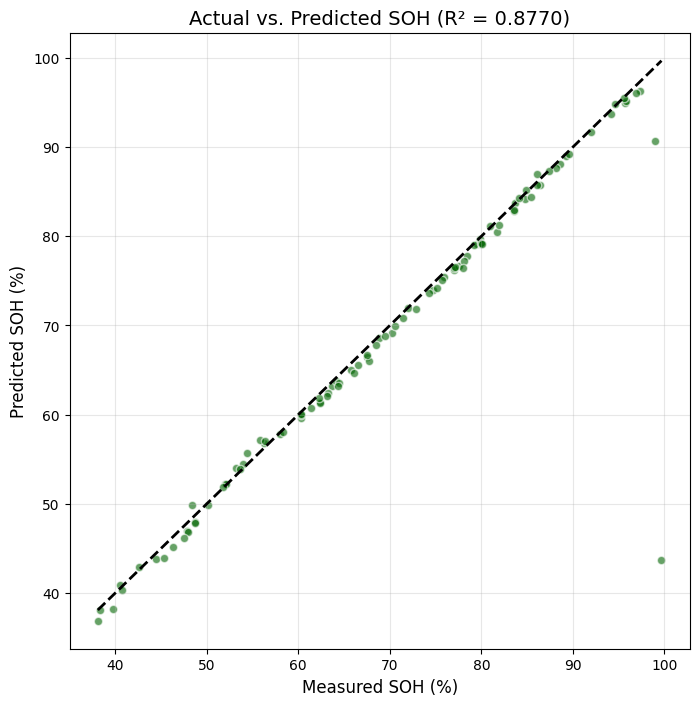

In [12]:
def plot_regression(y_actual, y_pred):
    plt.figure(figsize=(8, 8))
    plt.scatter(y_actual, y_pred, alpha=0.6, edgecolors='w', color='darkgreen')

    # Diagonal reference line
    line_range = [y_actual.min(), y_actual.max()]
    plt.plot(line_range, line_range, color='black', linestyle='--', lw=2)

    plt.title(f'Actual vs. Predicted SOH (R² = {r2_score(y_actual, y_pred):.4f})', fontsize=14)
    plt.xlabel('Measured SOH (%)', fontsize=12)
    plt.ylabel('Predicted SOH (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_regression(y_actual, y_pred)

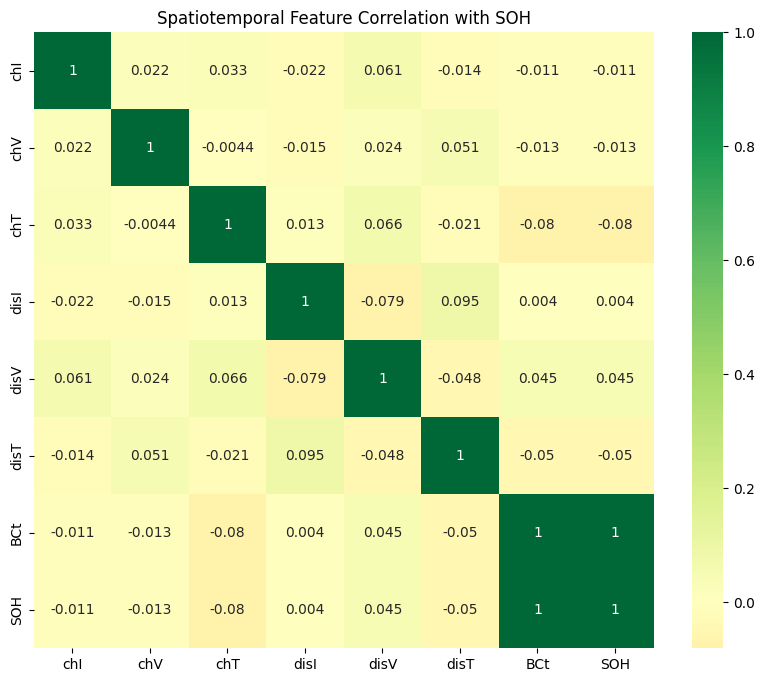

In [6]:
import seaborn as sns

def plot_feature_correlation(df, features, target):
    plt.figure(figsize=(10, 8))
    corr_matrix = df[features + [target]].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
    plt.title('Spatiotemporal Feature Correlation with SOH')
    plt.show()

plot_feature_correlation(df, features, target)

In [8]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np # Import numpy for np.sqrt

# 1. Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

# Define PARAM_BOUNDS based on the GA's search space
PARAM_BOUNDS = {
    "lstm_units": [32, 64, 128],
    "dense_units": [16, 32, 64],
    "dropout_rate": "0.1 to 0.5 (Uniform)",
    "learning_rate": [0.01, 0.001, 0.0001]
}

# 2. Create Hyperparameter Table
hp_data = {
    "Hyperparameter": ["LSTM Units", "Dense Units", "Dropout Rate", "Learning Rate", "Window Size (Cycles)"],
    "Search Space / Range": [
        str(PARAM_BOUNDS['lstm_units']),
        str(PARAM_BOUNDS['dense_units']),
        str(PARAM_BOUNDS['dropout_rate']),
        str(PARAM_BOUNDS['learning_rate']),
        str(WINDOW_SIZE) # Fixed, not part of GA search space
    ],
    "Optimal Value (EGA)": [
        best_config['lstm_units'],
        best_config['dense_units'],
        f"{best_config['dropout_rate']:.4f}", # Format for readability
        best_config['learning_rate'],
        WINDOW_SIZE
    ]
}

hp_df = pd.DataFrame(hp_data)

print("--- EGA OPTIMIZATION SUMMARY ---")
print(hp_df.to_string(index=False))
print("\n--- FINAL MODEL PERFORMANCE ---")
print(f"RMSE: {rmse:.5f}")
print(f"MAE:  {mae:.5f}")
print(f"R² Score: {r2:.5f}")

--- EGA OPTIMIZATION SUMMARY ---
      Hyperparameter  Search Space / Range Optimal Value (EGA)
          LSTM Units         [32, 64, 128]                 256
         Dense Units          [16, 32, 64]                  16
        Dropout Rate  0.1 to 0.5 (Uniform)              0.3000
       Learning Rate [0.01, 0.001, 0.0001]               0.005
Window Size (Cycles)                    10                  10

--- FINAL MODEL PERFORMANCE ---
RMSE: 5.68253
MAE:  1.30154
R² Score: 0.87702
